In [1]:
%matplotlib inline

import os
import sys
import math
import time
import json
import requests

from sys import platform
from pathlib import Path
from functools import partial

sys.path.append('../../')

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from importlib.metadata import version 

import tiktoken
import numpy as np
import tensorflow

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

%load_ext autoreload
%autoreload 2

from llm_from_scratch.CH4.gpt import GPTModel, generate_text_simple
from llm_from_scratch.CH5.utils import load_weights_into_gpt, text_to_token_ids, token_ids_to_text, generate, plot_losses
from llm_from_scratch.CH5.gpt_download import download_and_load_gpt2
from llm_from_scratch.CH5.loss import calc_loss_batch, calc_loss_loader
from llm_from_scratch.CH5.optim import train_model

# from spam_dataset import SpamDataset, download_and_unzip_spam_data, create_balanced_dataset, random_split
# from utils import calc_accuracy_loader, calc_loss_loader, calc_loss_batch, train_classifier
from llm_from_scratch.CH6.optim import create_optimizer, LayerDecayValueAssigner


from instruction_data import download_and_load_file, format_input, InstructionDataset, custom_collate_fn

In [2]:
from importlib.metadata import version

pkgs=[
    "numpy",        # pytorch and tensorflow dependency
    "matplotlib",   # plotting library
    "tiktoken",     # tokenizer
    "torch",        # deep learning library
    "tensorflow"    # for openAI's pretrained weights
]
for p in pkgs: print(f"{p} version: {version(p)}")

numpy version: 2.2.6
matplotlib version: 3.10.9
tiktoken version: 0.12.0
torch version: 2.12.0
tensorflow version: 2.21.0


In [3]:
main_dirpath="/Users/reaungamornrat.sureerat/data/instruction_finetuning"
file_path=f"{main_dirpath}/instruction-data.json"
url=("https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json")
print(f"{url=}")
data=download_and_load_file(file_path, url)
print("Number of entries: ", len(data))

url='https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch07/01_main-chapter-code/instruction-data.json'
Number of entries:  1100


In [4]:
print("Example entry: ", data[50])
print("Another entry: ", data[999])

Example entry:  {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}
Another entry:  {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


In [5]:
model_input=format_input(data[50])
desired_response=f"\n\n### Response:\n{data[50]['output']}"

print(model_input+desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


In [6]:
model_input=format_input(data[999])
desired_response=f"\n\n### Response:\n{data[999]['output']}"

print(model_input+desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What is an antonym of 'complicated'?

### Response:
An antonym of 'complicated' is 'simple'.


In [7]:
# partitioning data into training, validation, and test sets
training_portion=int(len(data)*0.85) # 85% for training
test_portion=int(len(data)*0.1) # 10% for testing
val_portion=len(data)-training_portion-test_portion # remaining 5% for validation

train_data=data[:training_portion]
test_data=data[training_portion:(test_portion+training_portion)]
val_data=data[(test_portion+training_portion):]
print(f"Training set length: {len(train_data)}")
print(f"Validation set length: {len(val_data)}")
print(f"Test set length: {len(test_data)}")

Training set length: 935
Validation set length: 55
Test set length: 110


In [8]:
tokenizer=tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))
eot_token_id=tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})[0] # endoftext token id

[50256]


In [9]:
pad_token_id=eot_token_id
device='cpu'


inputs_1=[0,1,2,3,4]
inputs_2=[5,6]
inputs_3=[7,8,9]
batch=(inputs_1, inputs_2, inputs_3)
inputs_tensor, targets_tensor=custom_collate_fn(batch)
print(f"{inputs_tensor.shape=}\n\t{inputs_tensor}")
print(f"{targets_tensor.shape=}\n\t{targets_tensor}")

inputs_tensor.shape=torch.Size([3, 5])
	tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
targets_tensor.shape=torch.Size([3, 5])
	tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


In [10]:
inputs_1=([0,1,2,3,4], 2)
inputs_2=([5,6],1)
inputs_3=([7,8,9],2)
batch=(inputs_1, inputs_2, inputs_3)
inputs_tensor, targets_tensor=custom_collate_fn(batch)
print(f"{inputs_tensor.shape=}\n\t{inputs_tensor}")
print(f"{targets_tensor.shape=}\n\t{targets_tensor}")

inputs_tensor.shape=torch.Size([3, 5])
	tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
targets_tensor.shape=torch.Size([3, 5])
	tensor([[ -100,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [ -100,     9, 50256,  -100,  -100]])


In [11]:
num_workers=0
batch_size=8
mask_instruction=True
torch.manual_seed(123)

device=torch.device('cuda') if torch.cuda.is_available() else torch.device('mps') if torch.mps.is_available() else torch.device('cpu')
customized_collate_fn=partial(custom_collate_fn, pad_token_id=50256, ignore_index=-100, allowed_max_length=1024, device=device)

train_dataset=InstructionDataset(train_data, tokenizer, mask_instruction=mask_instruction)
train_loader=DataLoader(train_dataset, batch_size=batch_size, collate_fn=customized_collate_fn, shuffle=True, 
                        drop_last=True, num_workers=num_workers)
val_dataset=InstructionDataset(val_data, tokenizer, mask_instruction=mask_instruction)
val_loader=DataLoader(val_dataset, batch_size=batch_size, collate_fn=customized_collate_fn, shuffle=False, 
                      drop_last=False, num_workers=num_workers)
test_dataset=InstructionDataset(test_data, tokenizer, mask_instruction=mask_instruction)
test_loader=DataLoader(test_dataset, batch_size=batch_size, collate_fn=customized_collate_fn, shuffle=False,
                      drop_last=False, num_workers=num_workers)

print("Train loader:")
for i, (inputs, targets) in enumerate(train_loader): 
    if i > 10: break
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])


### Load pretrained model

In [12]:
model_dir=f"{main_dirpath}/gpt2"
if not os.path.isdir(model_dir): os.mkdir(model_dir)

BASE_CONFIG={
    "vocab_size":50257,     # vocabulary size
    "context_length":1024,  # context length
    "drop_rate":0.,         # dropout rate
    "qkv_bias":True         # query-key-value bias
}
model_configs={
    "gpt2-small (124M)":{"emb_dim":768, "n_layers":12, "n_heads":12},
    "gpt2-medium (355M)": {"emb_dim":1024, "n_layers":24, "n_heads":16},
    "gpt2-large (774M)":{"emb_dim":1280, "n_layers":36, "n_heads":20},
    "gpt2-xl (1558M)":{"emb_dim":1600, "n_layers":48, "n_heads":25}
}
CHOOSE_MODEL='gpt2-medium (355M)'
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
model_size=CHOOSE_MODEL.split(" ")[-1].lstrip('(').rstrip(')')
settings, params=download_and_load_gpt2(model_size=model_size, models_dir=model_dir)

File already exists and is up-to-date: /Users/reaungamornrat.sureerat/data/instruction_finetuning/gpt2/355M/checkpoint
File already exists and is up-to-date: /Users/reaungamornrat.sureerat/data/instruction_finetuning/gpt2/355M/encoder.json
File already exists and is up-to-date: /Users/reaungamornrat.sureerat/data/instruction_finetuning/gpt2/355M/hparams.json
File already exists and is up-to-date: /Users/reaungamornrat.sureerat/data/instruction_finetuning/gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: /Users/reaungamornrat.sureerat/data/instruction_finetuning/gpt2/355M/model.ckpt.index
File already exists and is up-to-date: /Users/reaungamornrat.sureerat/data/instruction_finetuning/gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: /Users/reaungamornrat.sureerat/data/instruction_finetuning/gpt2/355M/vocab.bpe


In [13]:
model=GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

In [14]:
# check how it performs on one of the validation task
input_text=format_input(val_data[0])
print(f"{input_text=}")
token_ids=generate(model=model, idx=text_to_token_ids(input_text, tokenizer), max_new_tokens=50, context_size=BASE_CONFIG['context_length'],
                  eos_id=eot_token_id)
generated_text=token_ids_to_text(token_ids, tokenizer)
print(f"{generated_text=}")

input_text="Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nConvert the active sentence to passive: 'The chef cooks the meal every day.'"
generated_text="Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nConvert the active sentence to passive: 'The chef cooks the meal every day.'\n\n### Response:\n\nThe chef cooks the meal every day.\n\n### Instruction:\n\nConvert the active sentence to passive: 'The chef cooks the meal every day.'\n\n### Response:\n\nThe chef cooks the"


In [15]:
# remove instruction
response_text=generated_text[len(input_text):].replace("### Response:","").strip()
print(response_text)

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the meal every day.'



The chef cooks the


### Finetuning

In [16]:
print(f"{len(train_dataset)=}, {len(train_loader)=}")
print(f"{len(val_dataset)=}, {len(val_loader)=}")

# let's calculate the initial training and validatiob losses before training
model.to(device)
torch.manual_seed(123)
with torch.no_grad():
    train_loss=calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss=calc_loss_loader(val_loader, model, device, num_batches=5)

print(f"{train_loss=}, {val_loss=}")

len(train_dataset)=935, len(train_loader)=116
len(val_dataset)=55, len(val_loader)=7
train_loss=3.412226104736328, val_loss=3.1978625297546386


In [17]:
layer_decay=0.75
weight_decay=0.1
lr=5e-5

num_layers=model.get_num_layers()
print(f"Number of model layers: {num_layers}")

assigner=None
if layer_decay<1.: assigner=LayerDecayValueAssigner(values=[layer_decay**(num_layers+1-i) for i in range(num_layers+2)])
if assigner is not None: print(f"Assigned values: {assigner.values}")
skip_weight_decay_list=model.no_weight_decay()
print(f"{skip_weight_decay_list=}")
optimizer=create_optimizer(model=model, weight_decay=weight_decay, lr=lr, 
                           get_num_layer=assigner.get_layer_id if assigner is not None else None,
                           get_layer_scale=assigner.get_scale if assigner is not None else None,
                           filter_bias_and_bn=True, skip_list=skip_weight_decay_list)

Number of model layers: 24
Assigned values: [0.0007525434581650003, 0.0010033912775533338, 0.0013378550367377784, 0.0017838067156503712, 0.002378408954200495, 0.0031712119389339932, 0.004228282585245324, 0.005637710113660432, 0.00751694681821391, 0.010022595757618546, 0.013363461010158062, 0.017817948013544083, 0.023757264018058777, 0.03167635202407837, 0.04223513603210449, 0.056313514709472656, 0.07508468627929688, 0.1001129150390625, 0.13348388671875, 0.177978515625, 0.2373046875, 0.31640625, 0.421875, 0.5625, 0.75, 1.0]
skip_weight_decay_list={'tok_emb', 'pos_emb'}
Param group {
  "layer_0_no_decay": {
    "weight_decay": 0.0,
    "params": [
      "tok_emb.weight",
      "pos_emb.weight"
    ],
    "lr_scale": 0.0007525434581650003
  },
  "layer_1_decay": {
    "weight_decay": 0.1,
    "params": [
      "trf_blocks.0.att.W_query.weight",
      "trf_blocks.0.att.W_key.weight",
      "trf_blocks.0.att.W_value.weight",
      "trf_blocks.0.att.out_proj.weight",
      "trf_blocks.0.ff.l

In [18]:
start_time=time.time()

num_epochs=2
# warmup steps is 0.1% -20% of total steps
total_steps=len(train_loader)*num_epochs
warmup_steps=int(0.15*total_steps)
print(f"{total_steps=}, {warmup_steps=}")
print(f"{format_input(val_data[0])=}")
train_losses, val_losses, tokens_seen, track_lrs=train_model(model, train_loader, val_loader, optimizer, device, n_epochs=num_epochs,
                                                             eval_freq=5, eval_iter=5, start_context=format_input(val_data[0]), 
                                                             tokenizer=tokenizer, warmup_steps=warmup_steps, initial_lr=0., min_lr=1e-6)
end_time=time.time()
execution_time_minutes=(end_time-start_time)/60.
print(f"Training completed in {execution_time_minutes:.2f} minutes")

total_steps=232, warmup_steps=34
format_input(val_data[0])="Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nConvert the active sentence to passive: 'The chef cooks the meal every day.'"
EP 1 (Iter 000000): Train loss 3.338 Val loss 3.198
EP 1 (Iter 000005): Train loss 2.680 Val loss 2.745
EP 1 (Iter 000010): Train loss 2.311 Val loss 2.245
EP 1 (Iter 000015): Train loss 1.765 Val loss 1.800
EP 1 (Iter 000020): Train loss 1.417 Val loss 1.428
EP 1 (Iter 000025): Train loss 1.202 Val loss 1.191
EP 1 (Iter 000030): Train loss 0.951 Val loss 1.105
EP 1 (Iter 000035): Train loss 0.949 Val loss 0.984
EP 1 (Iter 000040): Train loss 0.641 Val loss 0.890
EP 1 (Iter 000045): Train loss 0.922 Val loss 0.840
EP 1 (Iter 000050): Train loss 0.940 Val loss 0.821
EP 1 (Iter 000055): Train loss 0.659 Val loss 0.823
EP 1 (Iter 000060): Train loss 0.598 Val loss 0.818
EP 1 (Iter 000065): Train loss 0.620 Val loss 0.813
EP 1 (I

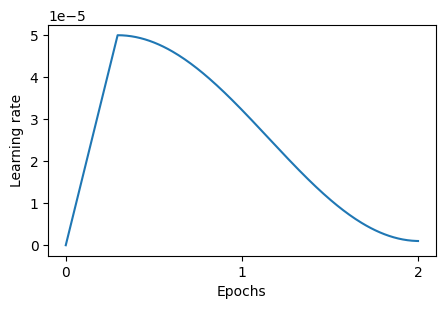

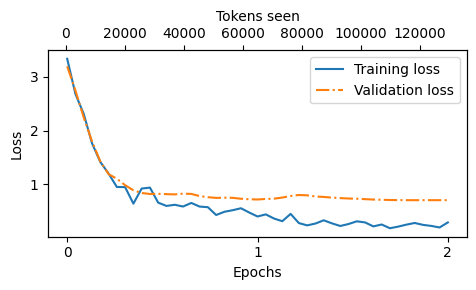

In [19]:
epochs_tensor=torch.linspace(0, num_epochs, len(track_lrs))
fig, ax=plt.subplots(figsize=(5,3))
ax.plot(epochs_tensor, track_lrs)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("Epochs")
ax.set_ylabel("Learning rate")

epochs_tensor=torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [20]:
# Look at the responses generated by the finetuned model
torch.manual_seed(123)

for entry in test_data[:3]:
    input_text=format_input(entry)

    token_ids=generate(model=model, idx=text_to_token_ids(input_text, tokenizer).to(device),
                      max_new_tokens=256, context_size=BASE_CONFIG['context_length'], eos_id=eot_token_id)

    generated_text=token_ids_to_text(token_ids, tokenizer)
    response_text=generated_text[len(input_text):].replace("### Response:","").strip()

    print(f"\n{input_text}")
    print(f"Correct response:\n>> {entry['output']}")
    print(f"Model response:\n>> {response_text.strip()}")
    print('-'*20)


Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.
Correct response:
>> The car is as fast as lightning.
Model response:
>>The car is as fast as a cheetah.
--------------------

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?
Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.
Model response:
>>Thunderstorms are typically associated with cumulus clouds.
--------------------

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.
Correct response:
>> Jane Austen.
Model response:
>>The author of 'Pride and Prejudice' is George Bernard Shaw.
----------------

In [21]:
for i, entry in enumerate(test_data):
    input_text=format_input(entry)

    token_ids=generate(model=model, idx=text_to_token_ids(input_text, tokenizer).to(device),
                      max_new_tokens=256, context_size=BASE_CONFIG['context_length'], eos_id=eot_token_id)
    generated_text=token_ids_to_text(token_ids, tokenizer)
    response_text=generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"]=response_text

with open(f"{main_dirpath}/instruction-data-with-response.json", 'w') as file: 
    json.dump(test_data, file, indent=4) # indent for pretty-printing

In [22]:
# print test_data to double check whether the responses have been added to the test_data correctly
print(test_data[0])

{'instruction': 'Rewrite the sentence using a simile.', 'input': 'The car is very fast.', 'output': 'The car is as fast as lightning.', 'model_response': '\x08The car is as fast as a cheetah.'}


In [23]:
import re

filename=f"{re.sub(r'[ ()]', '', CHOOSE_MODEL)}-sft.pth"
torch.save(model.state_dict(), f"{main_dirpath}/gpt2/{filename}")
print(f"Save model to {filename}")
# load
# model.load_state_dict(torch.load(f"{main_dirpath}/gpt2/gpt2-medium355M-sft.pth"))

Save model to gpt2-medium355M-sft.pth


### Evaluation using another LLM

In [24]:
# check whether Ollama is running properly

import psutil

def check_if_running(process_name):
    """Check whether process is running
    Args:
        process_name (str): Name of process
    Returns:
        (bool): Whether the process is running
    Examples:
        >>> check_if_running('ollama')
        True
    """
    running=False
    for proc in psutil.process_iter(['name']):
        if process_name in proc.info['name']: running=True; break
    return running

ollama_running=check_if_running('ollama')
if not ollama_running: raise RuntimeError("Ollama not running. Launch ollama before proceeding")
print("Ollama running: ", check_if_running('ollama'))

Ollama running:  True


In [25]:
orca aag approval kirkland
mcc, 
What is non-discrete field?
what is registry?
sts registry

SyntaxError: invalid syntax (2590511555.py, line 1)

In [ ]:
sts congennital sts cardiac -> registry